# Customer Sales Data Analysis

## Project Objective:
- Analyze sales data to identify trends, category performance, and profit patterns using NumPy, Pandas, and Matplotlib.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

## Data Understanding

In [2]:
df=pd.read_csv("SuperStoreOrders.csv")

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.tail()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
51285,CA-2014-115427,31-12-2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014
51289,CA-2014-156720,31-12-2014,4/1/2015,Standard Class,Jill Matthias,Consumer,Colorado,United States,US,West,...,Office Supplies,Fasteners,Bagged Rubber Bands,3,3,0.2,-0.6048,0.17,Medium,2014


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [13]:
df.shape

(51290, 21)

In [7]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

- Dataset contains 51,290 rows and 21 columns.
- No missing values in dataset.
- sales column is incorrectly stored as object.
- order_date and ship_date are not in datetime format.
- Dataset contains multiple categorical features like category, region, and segment.

## Data Cleaning

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True)

In [9]:
df['sales'] = df['sales'].replace('[\$,]', '', regex=True)
df['sales'] = pd.to_numeric(df['sales'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

## Feature Engineering

In [11]:
df['month'] = df['order_date'].dt.month

In [12]:
df['day'] = df['order_date'].dt.day_name()

In [13]:
df['profit_ratio'] = df['profit'] / df['sales']

In [14]:
df['shipping_time'] = (df['ship_date'] - df['order_date']).dt.days

In [15]:
df.head()


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quantity,discount,profit,shipping_cost,order_priority,year,month,day,profit_ratio,shipping_time
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2,0.0,106.140,35.46,Medium,2011,1,Saturday,0.260147,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,3,0.1,36.036,9.72,Medium,2011,1,Saturday,0.300300,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,4,0.0,29.640,8.17,High,2011,1,Saturday,0.449091,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,3,0.5,-26.055,4.82,High,2011,1,Saturday,-0.579000,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,5,0.1,37.770,4.70,Medium,2011,1,Saturday,0.331316,7


In [16]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year',
       'month', 'day', 'profit_ratio', 'shipping_time'],
      dtype='object')

### EDA

In [155]:
total_sales= df["sales"].sum()
total_sales

12642905

- Total sales show variation across years, indicating growth and fluctuation in business performance.
- Certain years contribute significantly higher revenue, suggesting periods of strong demand.

In [24]:
sales_by_category=df.groupby("category")["sales"].sum()
sales_by_category


category
Furniture          4110884
Office Supplies    3787330
Technology         4744691
Name: sales, dtype: int64

- Technology category generates the highest sales, making it the primary revenue driver.
- Furniture category shows relatively lower profit compared to sales, indicating higher costs or discount impact.
- Office Supplies show stable performance but lower overall contribution compared to Technology.

In [27]:
region_profit = df.groupby('region')['profit'].sum().sort_values()
region_profit

region
Canada             17817.39000
Southeast Asia     17852.32900
Caribbean          34571.32104
EMEA               43897.97100
Africa             88871.63100
East               91522.78000
West              108418.44890
Oceania           121666.64200
Central Asia      132480.18700
South             140355.76618
North Asia        165578.42100
North             194597.95252
Central           311403.98164
Name: profit, dtype: float64

- The West region generates the highest profit, making it the most profitable region.
- Some regions show high sales but lower profit, indicating inefficiency or higher operational costs.

In [163]:
sales_trend_year = df.groupby("year")["sales"].sum()
sales_trend_year

year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: sales, dtype: int64

In [164]:
monthly_sales= df.groupby("month")["sales"].sum()
monthly_sales

month
1      675141
2      543768
3      770519
4      698603
5      904061
6     1269751
7      749423
8     1293852
9     1437432
10    1168220
11    1551319
12    1580816
Name: sales, dtype: int64

- Sales vary across months, showing clear seasonal patterns.
- Certain months consistently record higher sales, indicating peak business periods.

In [166]:
Average_Profit_Ratio_by_Category= df.groupby("category")["profit_ratio"].mean()
Average_Profit_Ratio_by_Category

category
Furniture          0.008748
Office Supplies        -inf
Technology         0.049658
Name: profit_ratio, dtype: float64

In [169]:
Top_5_products_profit= df.groupby("product_name")["profit"].sum()
Top_5_products_profit.sort_values(ascending=False).head(5)

product_name
Canon imageCLASS 2200 Advanced Copier    25199.9280
Cisco Smart Phone, Full Size             17238.5206
Motorola Smart Phone, Full Size          17027.1130
Hoover Stove, Red                        11807.9690
Sauder Classic Bookcase, Traditional     10672.0730
Name: profit, dtype: float64

In [172]:
Most_sold_products= df.groupby("product_name")["quantity"].sum()
Most_sold_products.sort_values(ascending=False).head(5)

product_name
Staples                                  876
Cardinal Index Tab, Clear                337
Eldon File Cart, Single Width            321
Rogers File Cart, Single Width           262
Sanford Pencil Sharpener, Water Color    259
Name: quantity, dtype: int64

- Some products generate high sales but low profit, indicating poor pricing strategy.
- A few products contribute significantly to total profit, showing key revenue drivers.

In [176]:
discount_vs_profit= df[['discount', 'profit']].corr()
discount_vs_profit

,discount,profit
discount,1.000000,-0.316375
profit,-0.316375,1.000000


- There is a moderate negative relationship between discount and profit.
- Increasing discounts leads to reduced profit margins.
- Discounts may increase sales volume but negatively impact profitability.

In [174]:
df.groupby('discount')['profit'].mean().sort_index()

discount
0.000      61.039514
0.002     125.762649
0.070     140.990022
0.100      64.071216
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.202     -14.518847
0.250       4.043371
0.270      -4.317213
0.300     -57.899557
0.320     -88.560656
0.350    -116.144693
0.370     -78.462191
0.400     -45.246603
0.402    -109.908138
0.450     -41.610973
0.470     -42.982420
0.500     -97.140158
0.550    -315.067200
0.570    -526.129000
0.600     -81.732147
0.602    -213.279085
0.650    -365.997971
0.700    -104.339576
0.800    -122.203244
0.850   -1534.329000
Name: profit, dtype: float64

In [184]:
loss_df = df[df['profit'] < 0]
loss_products = loss_df.groupby('product_name')['profit'].sum()

In [185]:
loss_products = loss_products.sort_values()
loss_products.head(5)

product_name
Cubify CubeX 3D Printer Double Head Print   -9239.9692
Hoover Stove, White                         -6941.3190
GBC DocuBind P400 Electric Binding System   -6859.3896
Apple Smart Phone, Full Size                -6561.1119
Motorola Smart Phone, Cordless              -6511.9380
Name: profit, dtype: float64

- Several products generate negative profit, indicating business losses.
- These products require pricing review or discount reduction.

In [186]:
# Sales vs Profit by Category
category_analysis = df.groupby('category')[['sales','profit']].sum().sort_values(by='sales', ascending=False)
category_analysis

,sales,profit
category,,
Technology,4744691,663778.73318
Furniture,4110884,286782.25380
Office Supplies,3787330,518473.83430


- Technology category contributes the highest share of total sales
- Profit decreases as discount increases, showing a negative correlation
- A small number of products contribute a large portion of total profit
- Some orders generate high sales but result in negative profit
- Sales show consistent growth across years

In [187]:
# Region-wise performance
region_analysis = df.groupby('region')[['sales','profit']].sum().sort_values(by='profit', ascending=False)
region_analysis

,sales,profit
region,,
Central,2822399,311403.98164
North,1248192,194597.95252
North Asia,848349,165578.42100
South,1600960,140355.76618
Central Asia,752839,132480.18700
Oceania,1100207,121666.64200
West,725514,108418.44890
East,678834,91522.78000
Africa,783776,88871.63100


- The West region generates the highest profit, making it the most profitable market.
- Some regions show good sales but lower profit, indicating inefficiency or higher costs.

In [20]:
discount_quantity = df.groupby('discount')['quantity'].mean().sort_index()
discount_quantity.head()

discount
0.000    3.404736
0.002    3.594360
0.070    3.553333
0.100    3.789823
0.150    3.735675
Name: quantity, dtype: float64

In [189]:
# Segment Analysis
segment_analysis = df.groupby('segment')[['sales','profit']].sum().sort_values(by='profit', ascending=False)
segment_analysis

,sales,profit
segment,,
Consumer,6508141,749239.78206
Corporate,3824808,442785.85866
Home Office,2309956,277009.18056


- Certain customer segments contribute more to profit than others.
- Targeting high-value segments can improve overall business performance.

## summary
- Business performance is driven mainly by the Technology category and specific high-performing products.
- Discount strategies negatively impact profitability and must be optimized.
- Regional and seasonal trends play an important role in sales performance.
- Identifying loss-making products and improving pricing strategy can increase overall profit.

## Insights

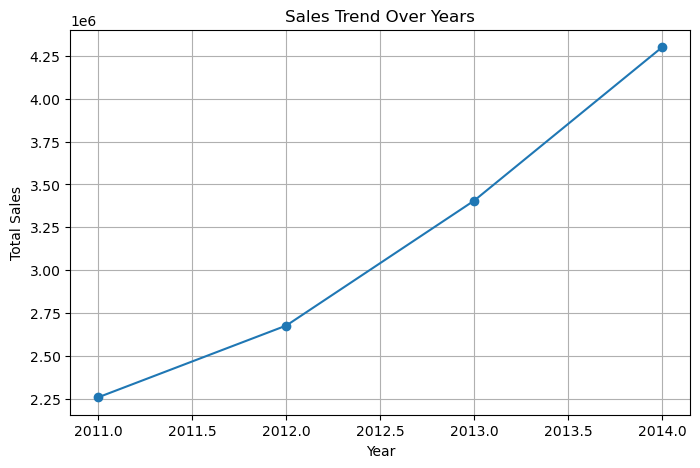

In [22]:
year_sales = df.groupby('year')['sales'].sum()

plt.figure(figsize=(8,5))
plt.plot(year_sales.index, year_sales.values, marker='o')
plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

- Sales show an overall increasing trend across years.
- Growth becomes stronger in later years.
- Business performance improves over time.

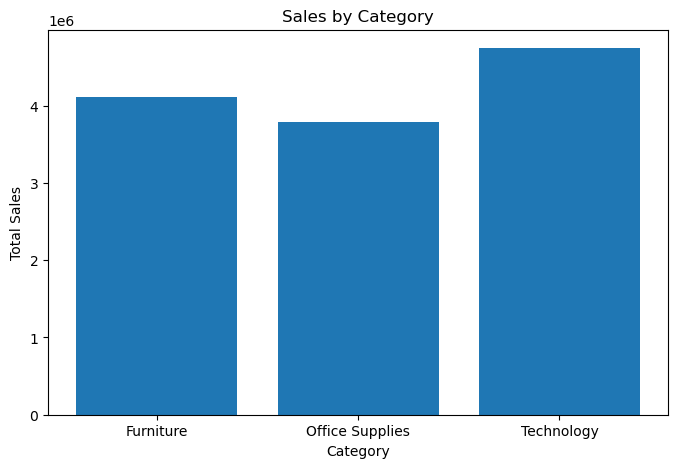

In [25]:
plt.figure(figsize=(8,5))
plt.bar(sales_by_category.index, sales_by_category.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

- Technology generates the highest sales
- Furniture shows moderate sales
- Office Supplies contribute consistently but lower than Technology
### High sales category is not always most profitable

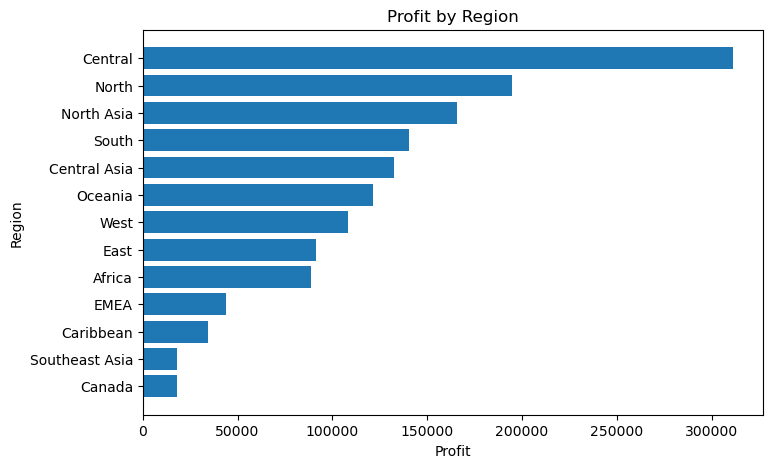

In [39]:

plt.figure(figsize=(8,5))
plt.barh(region_profit.index, region_profit.values)
plt.title("Profit by Region")
plt.xlabel("Profit")
plt.ylabel("Region")
plt.show()

- One region dominates total profit
- Some regions generate lower profit despite sales
- Indicates regional performance imbalance

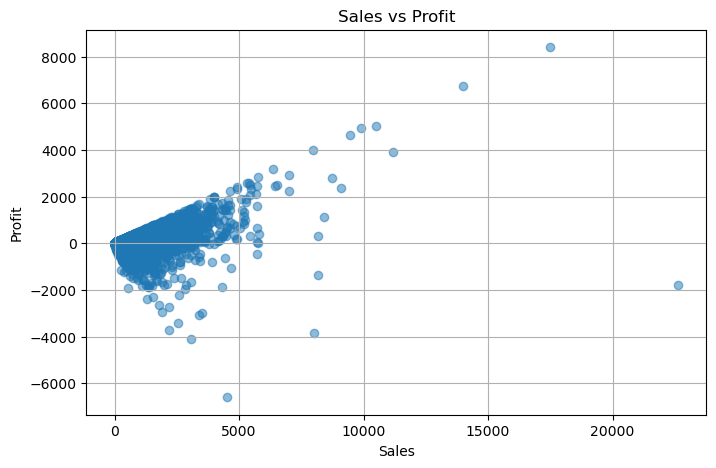

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['sales'], df['profit'], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

- No perfect linear relationship between sales and profit
- Some high sales points have low or negative profit
- Indicates discount or cost impact

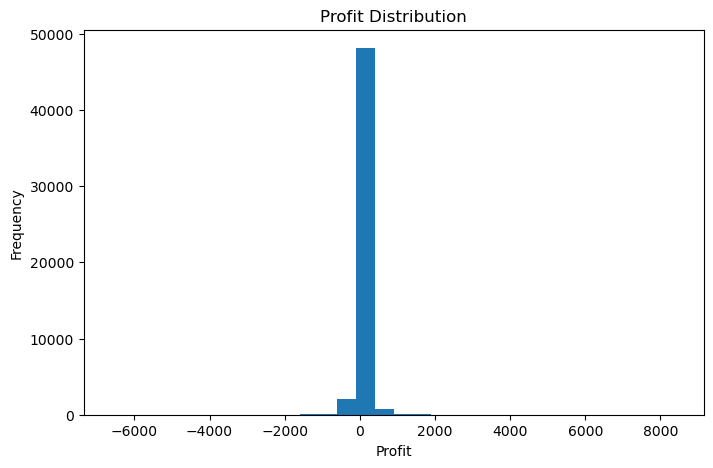

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df['profit'], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

- Profit distribution is skewed
- Many small profits, few high profits
- Presence of negative profit values (loss-making orders)

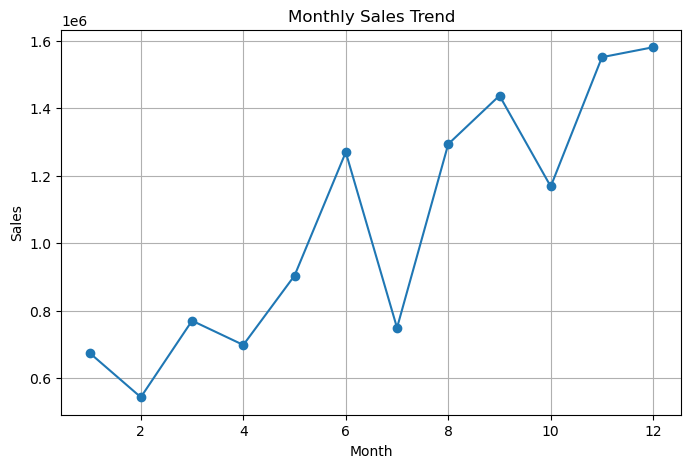

In [41]:
monthly_sales = df.groupby('month')['sales'].sum().sort_index()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

- Certain months show peak sales
- Indicates seasonal demand
- Some months consistently perform lower

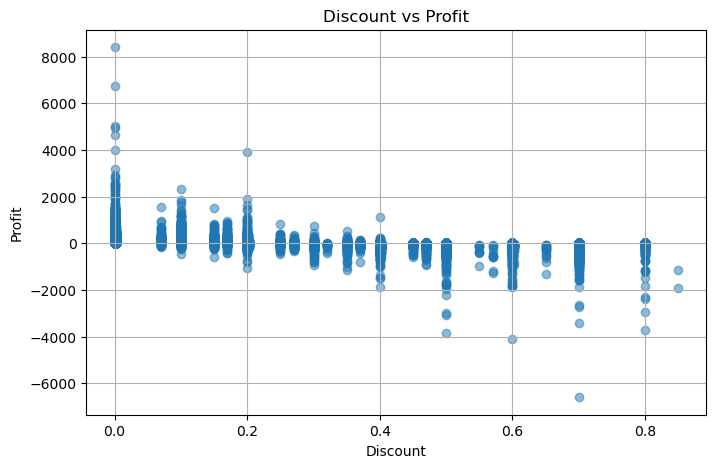

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df['discount'], df['profit'], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

- Clear negative trend
- Higher discounts reduce profit
- Confirms your correlation result (-0.316)

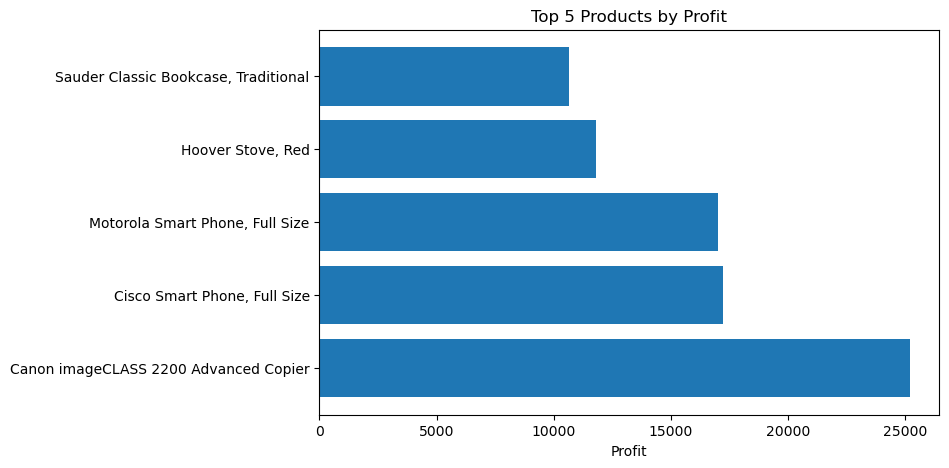

In [33]:
top_profit = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.barh(top_profit.index, top_profit.values)
plt.title("Top 5 Products by Profit")
plt.xlabel("Profit")
plt.show()

- Few products contribute major profit
- Profit concentration is high
- Important products for business focus

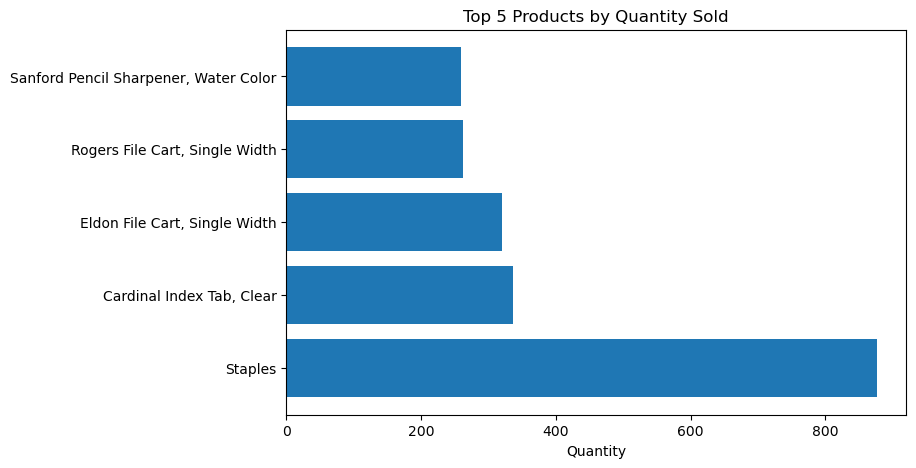

In [34]:
top_quantity = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.barh(top_quantity.index, top_quantity.values)
plt.title("Top 5 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.show()

- High-selling products differ from high-profit products
- Volume ≠ profitability

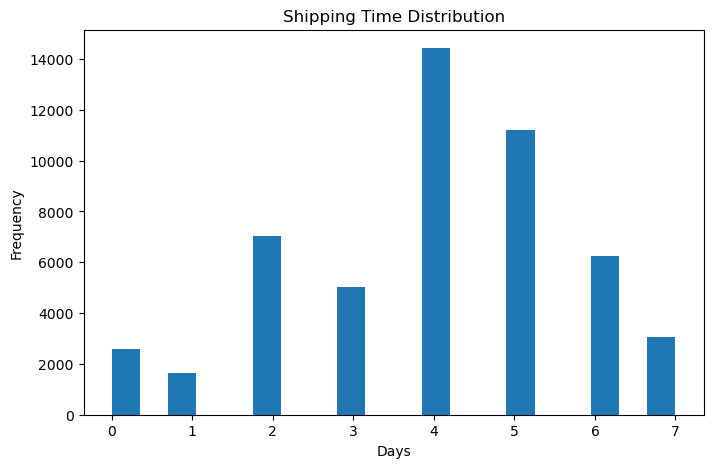

In [36]:
plt.figure(figsize=(8,5))
plt.hist(df['shipping_time'], bins=20)
plt.title("Shipping Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

- Most deliveries happen within a specific range
- Few extreme delays exist
- Delivery system is mostly consistent

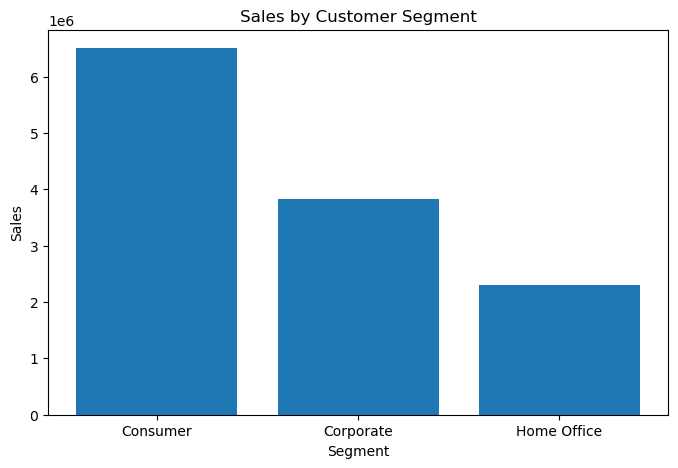

In [37]:
segment_sales = df.groupby('segment')['sales'].sum()

plt.figure(figsize=(8,5))
plt.bar(segment_sales.index, segment_sales.values)
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()

- One segment dominates sales
- Other segments contribute less
- Helps target key customer group

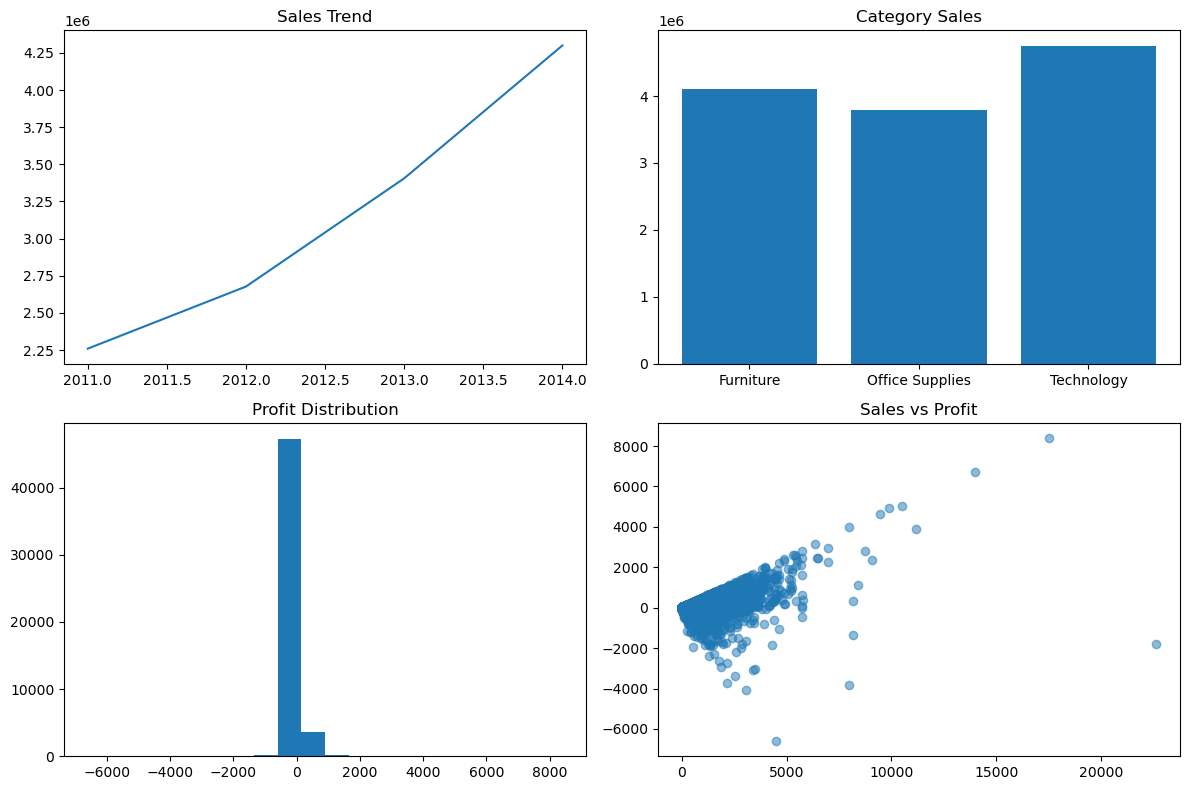

In [44]:
plt.figure(figsize=(12,8))

# 1. Sales Trend
plt.subplot(2,2,1)
plt.plot(year_sales.index, year_sales.values)
plt.title("Sales Trend")

# 2. Category Sales
plt.subplot(2,2,2)
plt.bar(sales_by_category.index, sales_by_category.values)
plt.title("Category Sales")

# 3. Profit Distribution
plt.subplot(2,2,3)
plt.hist(df['profit'], bins=20)
plt.title("Profit Distribution")

# 4. Sales vs Profit
plt.subplot(2,2,4)
plt.scatter(df['sales'], df['profit'], alpha=0.5)
plt.title("Sales vs Profit")

plt.tight_layout()
plt.show()

## Business Recommendations
- Reduce high discounts on low-margin products to improve profitability
- Focus on high-profit products instead of only high-selling products
- Improve performance in low-profit regions through targeted strategies
- Optimize pricing strategy to balance sales volume and profit
- Identify and eliminate loss-making transactions


## Summary

- This project analyzed customer sales data using Pandas and Matplotlib to understand sales performance, profitability, and business patterns.

- The analysis shows that overall sales increased steadily over the years, indicating business growth. Among product categories, Technology generates the highest revenue, while other categories contribute less consistently.

- Regional analysis reveals that profit is not evenly distributed, with some regions performing significantly better than others. This suggests the need for region-specific strategies.

- A key finding is the impact of discounts on profitability. There is a negative relationship between discount and profit, meaning higher discounts often reduce profit. This highlights the importance of controlling discount strategies.

- Product-level analysis shows that high-selling products are not always the most profitable. Some products generate high sales volume but low or negative profit, indicating inefficiencies.

- The profit distribution also shows the presence of loss-making transactions, which require attention. Additionally, seasonal trends in monthly sales suggest that demand varies across the year.

- Overall, the project demonstrates that focusing on high-profit products, optimizing discount strategies, and improving regional performance can significantly improve business outcomes.

# Conclusion
- This analysis helps businesses make data-driven decisions to improve revenue and profitability.
